In [8]:
!pip install opencv-python matplotlib "numpy<2"

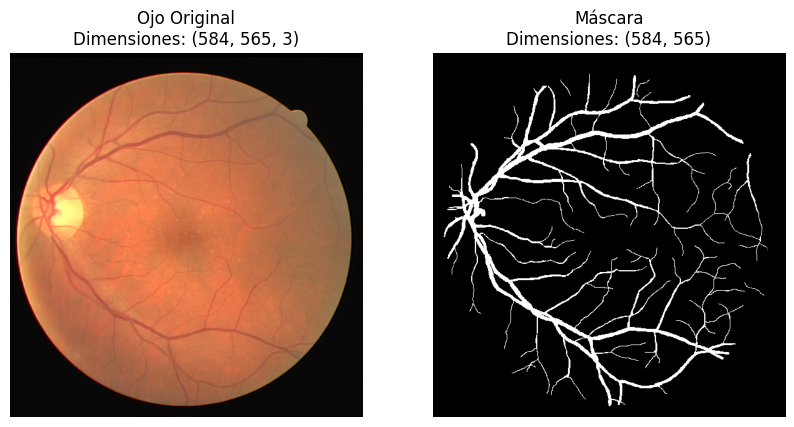

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Definimos las rutas a la primera imagen de tu dataset
ruta_ojo = "../data/training/images/21_training.tif"
ruta_mask = "../data/training/1st_manual/21_manual1.gif"

# TODO 1: LEER LAS IMÁGENES
# Cargamos la imagen a color (Ojo: OpenCV la carga en formato BGR)
ojo_bgr = cv2.imread(ruta_ojo)
# Cargamos la máscara indicándole explícitamente que es en escala de grises (1 solo canal)
mask = cv2.imread(ruta_mask, cv2.IMREAD_GRAYSCALE)

# Arreglamos el color de la foto original pasándola de BGR a RGB
ojo_rgb = cv2.cvtColor(ojo_bgr, cv2.COLOR_BGR2RGB)

# La Máscara (Como es .gif, usamos Pillow y lo pasamos a matriz NumPy)
mask_pil = Image.open(ruta_mask)
mask = np.array(mask_pil)

# TODO 2: NORMALIZACIÓN
# Las matrices vienen con valores de 0 a 255. Las dividimos para tenerlas entre 0.0 y 1.0
ojo_norm = ojo_rgb / 255.0
mask_norm = mask / 255.0

# Pintamos el resultado para comprobar que todo está bien
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(ojo_norm)
axs[0].set_title(f"Ojo Original\nDimensiones: {ojo_norm.shape}")
axs[0].axis('off')

axs[1].imshow(mask_norm, cmap='gray')
axs[1].set_title(f"Máscara\nDimensiones: {mask_norm.shape}")
axs[1].axis('off')

plt.show()

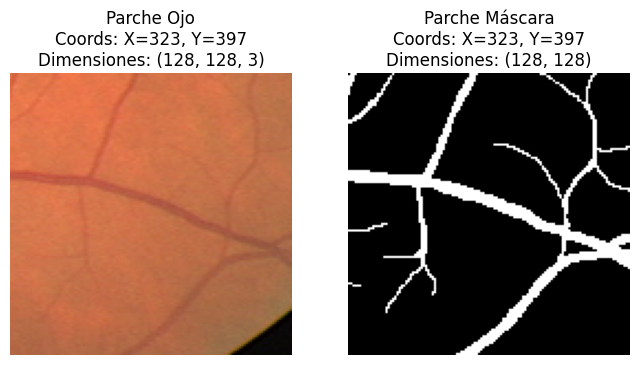

In [15]:
import random

# TODO 3: EL PARCHEADO (Troceado coordinado)
tamano_parche = 128

# 1. Obtenemos el alto y ancho de la imagen original
# .shape nos da (alto, ancho, canales). Con [:2] cogemos solo los dos primeros valores.
alto_original, ancho_original = ojo_norm.shape[:2]

# 2. Calculamos el límite máximo seguro para empezar a recortar
limite_y = alto_original - tamano_parche
limite_x = ancho_original - tamano_parche

# 3. Generamos las coordenadas 'y' y 'x' iniciales al azar
y_inicio = random.randint(0, limite_y)
x_inicio = random.randint(0, limite_x)

# 4. Aplicamos el recorte coordinado (Slicing) a las dos matrices a la vez
# Sintaxis: matriz[y_inicio : y_fin, x_inicio : x_fin]
parche_ojo = ojo_norm[y_inicio : y_inicio + tamano_parche, x_inicio : x_inicio + tamano_parche]
parche_mask = mask_norm[y_inicio : y_inicio + tamano_parche, x_inicio : x_inicio + tamano_parche]

# Pintamos el resultado para verificar la sincronización
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(parche_ojo)
axs[0].set_title(f"Parche Ojo\nCoords: X={x_inicio}, Y={y_inicio}\nDimensiones: {parche_ojo.shape}")
axs[0].axis('off')

axs[1].imshow(parche_mask, cmap='gray')
axs[1].set_title(f"Parche Máscara\nCoords: X={x_inicio}, Y={y_inicio}\nDimensiones: {parche_mask.shape}")
axs[1].axis('off')

plt.show()